# Tabulated SFH to Mock SED

**Spine:** run after [`02_sfh_gallery.py`](02_sfh_gallery.py) (parametric and GP priors) and
[`01_sed_anatomy.py`](01_sed_anatomy.py) (full forward model). This notebook is for **known**
$(t,\mathrm{SFR})$ tables — e.g. from hydrodynamic simulations, semi-analytic models, or custom
mocks — **without** `Parameters` or `SEDModel.mock`.

The [`tengri.simulate`](https://github.com/suchethac/tengri/blob/main/src/tengri/simulate.py)
helpers call the same CSP machinery as the rest of tengri (paper §3.1). To **infer** physical
parameters from data, use `SEDModel` + `Fitter` as in [`07_fitting_photometry.py`](07_fitting_photometry.py).

In [1]:
import os
import sys
import time
import warnings

try:
    _nb_dir = os.path.dirname(os.path.abspath(__file__))
    _repo_root = os.path.abspath(os.path.join(_nb_dir, ".."))
except NameError:
    _nb_dir = os.getcwd()
    _repo_root = os.path.abspath(os.path.join(_nb_dir, ".."))

# Prefer this checkout's ``src/tengri`` over any other installed ``tengri`` (nbclient/Jupyter).
_src = os.path.join(_repo_root, "src")
if os.path.isdir(os.path.join(_src, "tengri")):
    sys.path.insert(0, _src)
sys.path.insert(0, _repo_root)
sys.path.insert(0, _nb_dir)

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", category=FutureWarning)

from tengri import load_filter_set, load_ssp_data
from tengri.analysis.simulate import photometry_from_sfh, sed_from_sfh

import importlib.util

_repo_data_root = None
_spec_tengri = importlib.util.find_spec("tengri")
if _spec_tengri is not None and _spec_tengri.origin:
    _walk = os.path.dirname(os.path.abspath(_spec_tengri.origin))
    for _step in range(12):
        _candidate = os.path.join(_walk, "notebooks", "_plot_style.py")
        if os.path.isfile(_candidate):
            sys.path.insert(0, os.path.dirname(_candidate))
            _repo_data_root = os.path.dirname(os.path.dirname(os.path.abspath(_candidate)))
            break
        _parent_walk = os.path.dirname(_walk)
        if _parent_walk == _walk:
            break
        _walk = _parent_walk

if _repo_data_root is None:
    _np_here = os.path.abspath(os.getcwd())
    while True:
        if os.path.isfile(os.path.join(_np_here, "_plot_style.py")):
            sys.path.insert(0, _np_here)
            _repo_data_root = os.path.dirname(_np_here)
            break
        _ppt = os.path.join(_np_here, "notebooks", "_plot_style.py")
        if os.path.isfile(_ppt):
            _nbsd = os.path.dirname(_ppt)
            sys.path.insert(0, _nbsd)
            _repo_data_root = os.path.dirname(_nbsd)
            break
        _parent_here = os.path.dirname(_np_here)
        if _parent_here == _np_here:
            break
        _np_here = _parent_here

if _repo_data_root is not None and os.path.isdir(os.path.join(_repo_data_root, "data")):
    os.chdir(_repo_data_root)
elif os.path.isdir(os.path.join(_repo_root, "data")):
    os.chdir(_repo_root)
elif os.path.isdir("data"):
    pass
elif os.path.isdir(os.path.join("..", "data")):
    os.chdir("..")

from _plot_style import COLORS, setup_style

setup_style()

FIGDIR = os.path.join("notebooks", "figures", "13_tabulated_sfh")
os.makedirs(FIGDIR, exist_ok=True)

W0422 23:36:46.107541 22820089 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


In [2]:
ssp_data = load_ssp_data("data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5")
filters = load_filter_set(["sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z"])

## 1. Archetypal tabulated SFHs

Cosmic time in Gyr (increasing) and $\mathrm{SFR}$ in $M_\odot\,\mathrm{yr}^{-1}$, as you would
dump from a simulation post-processing pipeline.

In [3]:
t_gyr = np.linspace(0.5, 13.7, 200)

sfh_library = {
    "Exponential decline": {
        "sfr": 30.0 * np.exp(-t_gyr / 3.0),
        "color": COLORS["rt"],
        "log_z": -0.3,
    },
    "Delayed-tau": {
        "sfr": 15.0 * (t_gyr / 3.0) * np.exp(-t_gyr / 3.0),
        "color": COLORS["vi"],
        "log_z": -0.5,
    },
    "Late-time burst": {
        "sfr": 5.0 * np.exp(-t_gyr / 5.0) + 50.0 * np.exp(-0.5 * ((t_gyr - 10.0) / 0.5) ** 2),
        "color": COLORS["mcmc_nuts"],
        "log_z": -0.2,
    },
    "Constant + quench": {
        "sfr": 10.0 * np.where(t_gyr < 8.0, 1.0, np.exp(-(t_gyr - 8.0) / 0.5)),
        "color": COLORS.get("vi_linear", "C4"),
        "log_z": -0.1,
    },
}

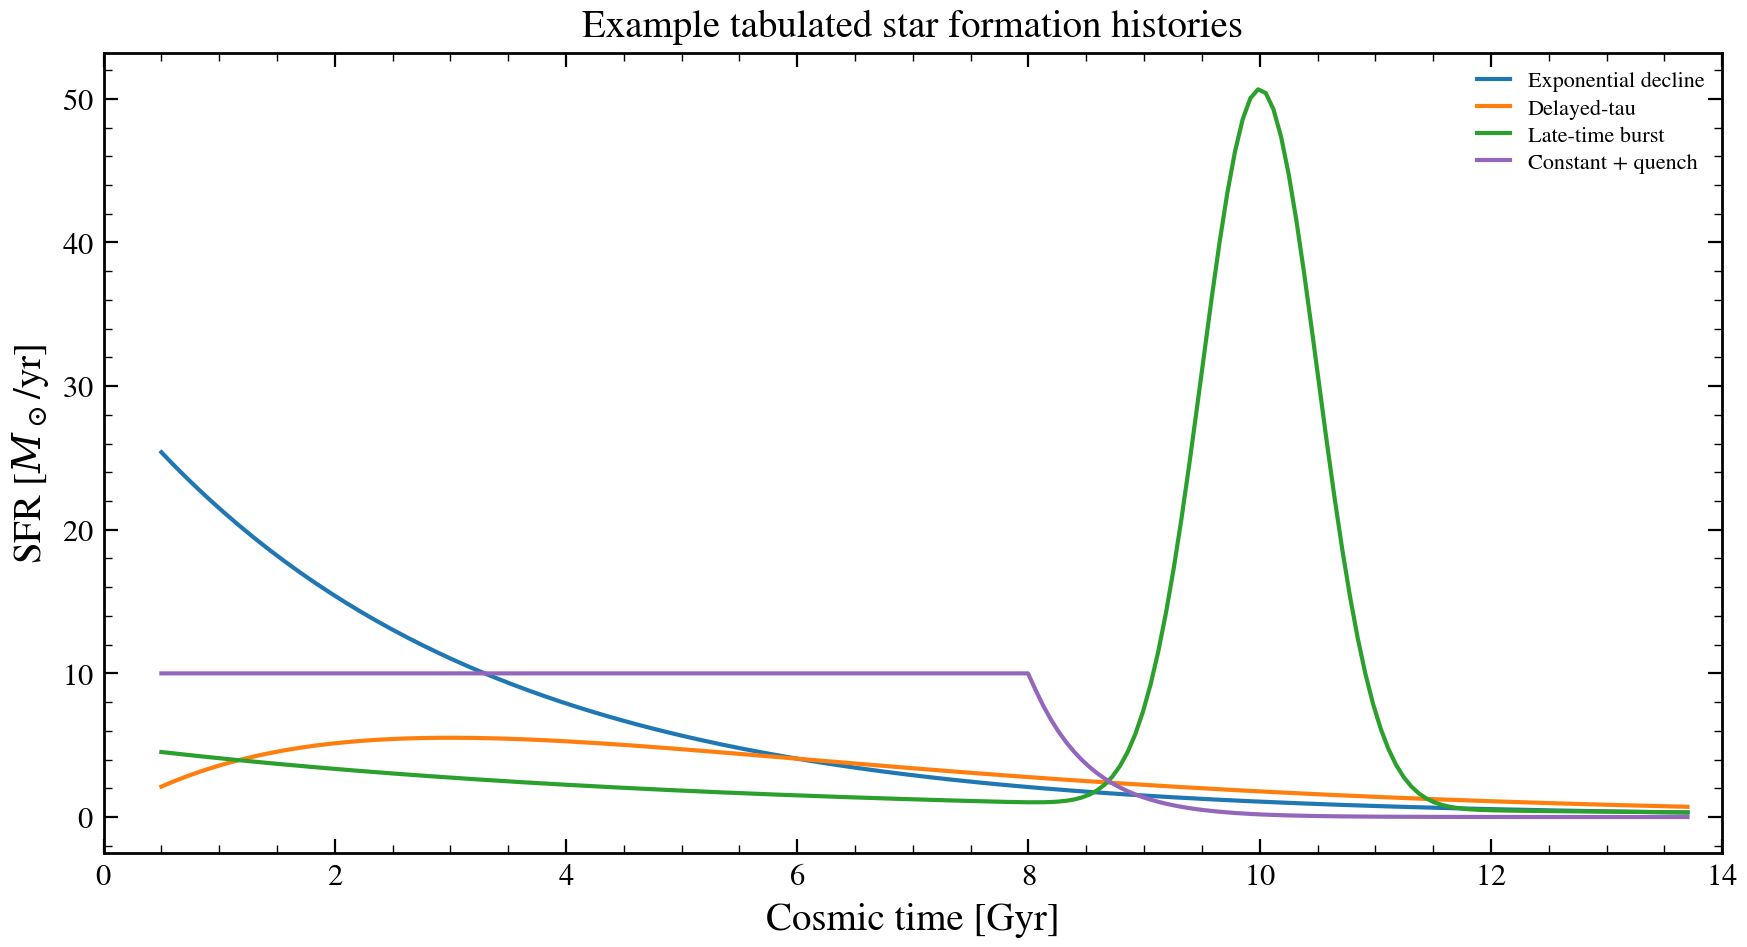

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
for name, sfh in sfh_library.items():
    ax.plot(t_gyr, sfh["sfr"], color=sfh["color"], lw=1.5, label=name)
ax.set_xlabel("Cosmic time [Gyr]")
ax.set_ylabel(r"SFR [$M_\odot$/yr]")
ax.set_title("Example tabulated star formation histories")
ax.legend(fontsize=8, frameon=False)
ax.set_xlim(0, 14)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "tabulated_sfhs.png"), dpi=150, bbox_inches="tight")
plt.show()

## 2. Rest-frame SED from each SFH

`sed_from_sfh` integrates the CSP (scalar or $Z(t)$ metallicity,
optional Charlot–Fall dust). Output wavelengths are rest-frame Å; SED is $L_\nu$ in
erg s$^{-1}$ Hz$^{-1}$.

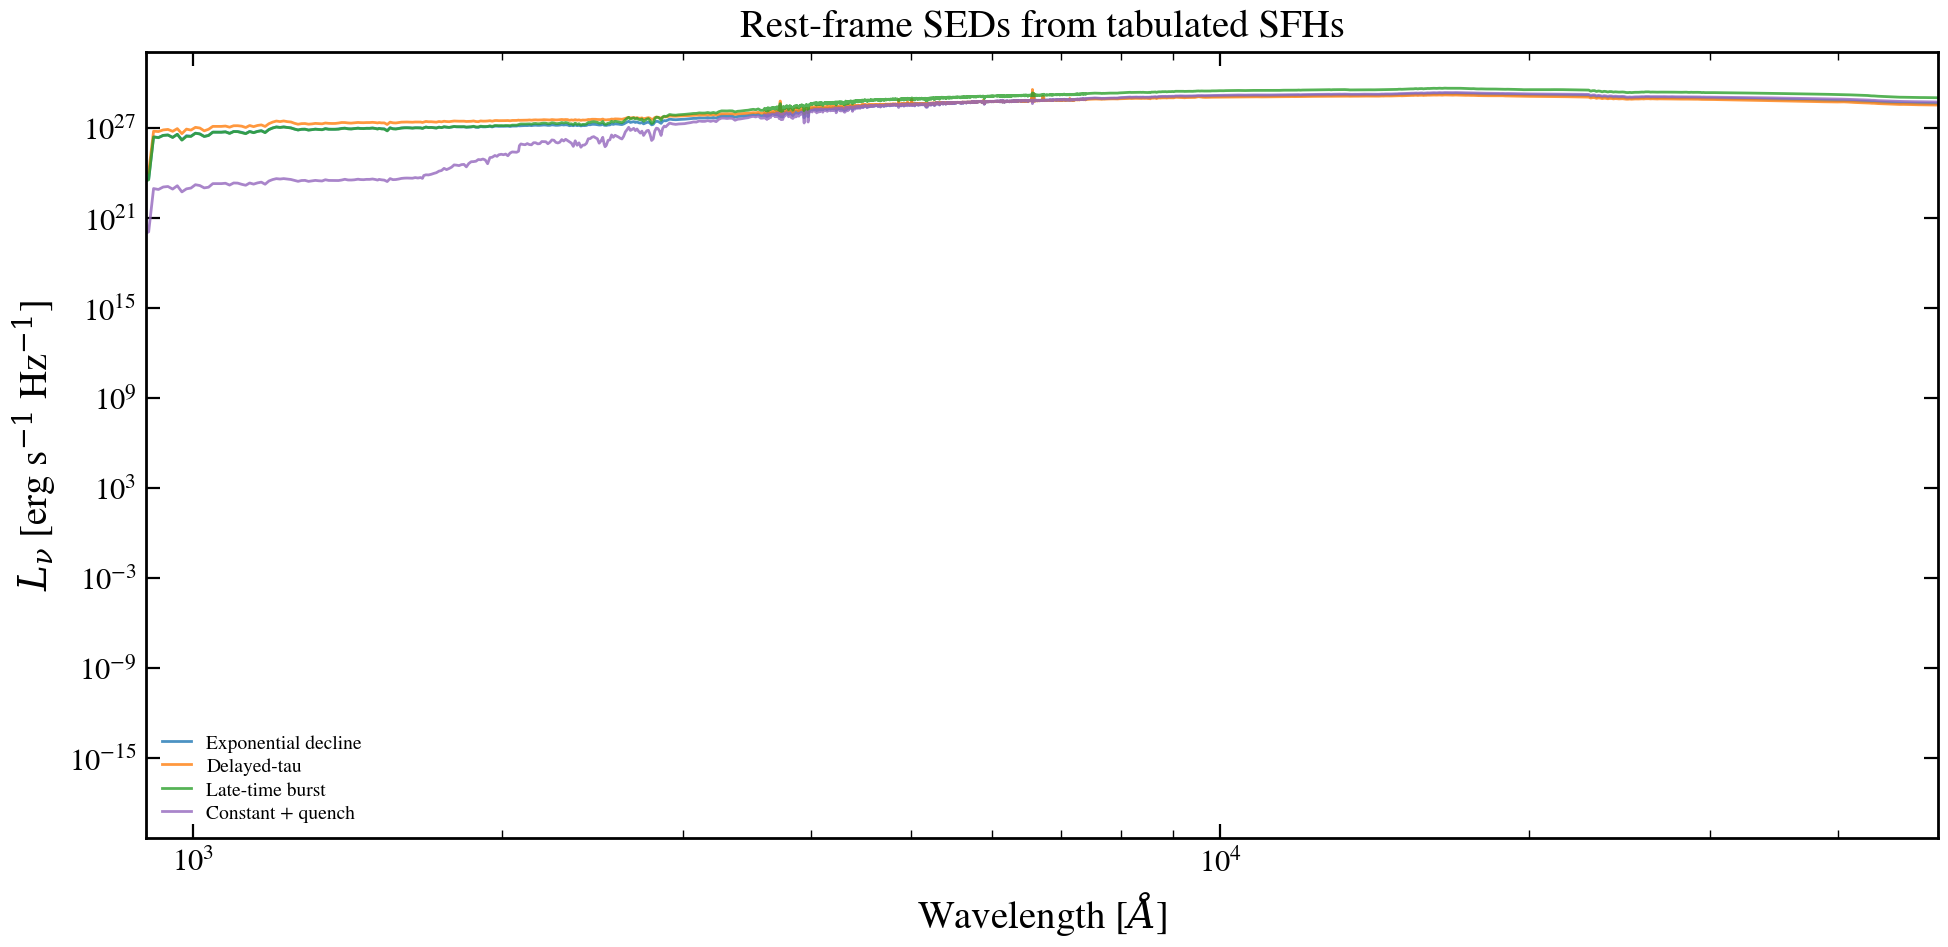

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

for name, sfh in sfh_library.items():
    result = sed_from_sfh(
        jnp.array(t_gyr),
        jnp.array(sfh["sfr"]),
        ssp_data,
        log_z=sfh["log_z"],
        dust_tau_bc=0.3,
        dust_tau_diff=0.5,
    )
    wave = np.array(result["wavelength"])
    sed = np.array(result["sed"])
    ax.loglog(wave, sed, color=sfh["color"], lw=1.0, label=name, alpha=0.8)

ax.set_xlabel(r"Wavelength [$\AA$]")
ax.set_ylabel(r"$L_\nu$ [erg s$^{-1}$ Hz$^{-1}$]")
ax.set_title("Rest-frame SEDs from tabulated SFHs")
ax.set_xlim(900, 50000)
ax.legend(fontsize=7, frameon=False)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "tabulated_seds.png"), dpi=150, bbox_inches="tight")
plt.show()

## 3. Mock broadband fluxes at $z=0.1$

`photometry_from_sfh` convolves the SED through filters,
applies IGM transmission, and scales by luminosity distance. Use the result as **truth** fluxes
for mock challenges, then fit with `SEDModel` + `Fitter`.

In [6]:
z_demo = 0.1
name_demo = "Delayed-tau"
sfr_demo = sfh_library[name_demo]["sfr"]
logz_demo = sfh_library[name_demo]["log_z"]

phot = photometry_from_sfh(
    jnp.array(t_gyr),
    jnp.array(sfr_demo),
    ssp_data,
    filters,
    log_z=logz_demo,
    redshift=z_demo,
    dust_tau_bc=0.3,
    dust_tau_diff=0.5,
    apply_igm=True,
)
print("Filter fluxes (erg/s/cm²/Hz):", np.array(phot["flux"]))

Filter fluxes (erg/s/cm²/Hz): [3.46869609e-28 1.20027474e-27 2.18285535e-27 3.03282723e-27
 3.92334373e-27]


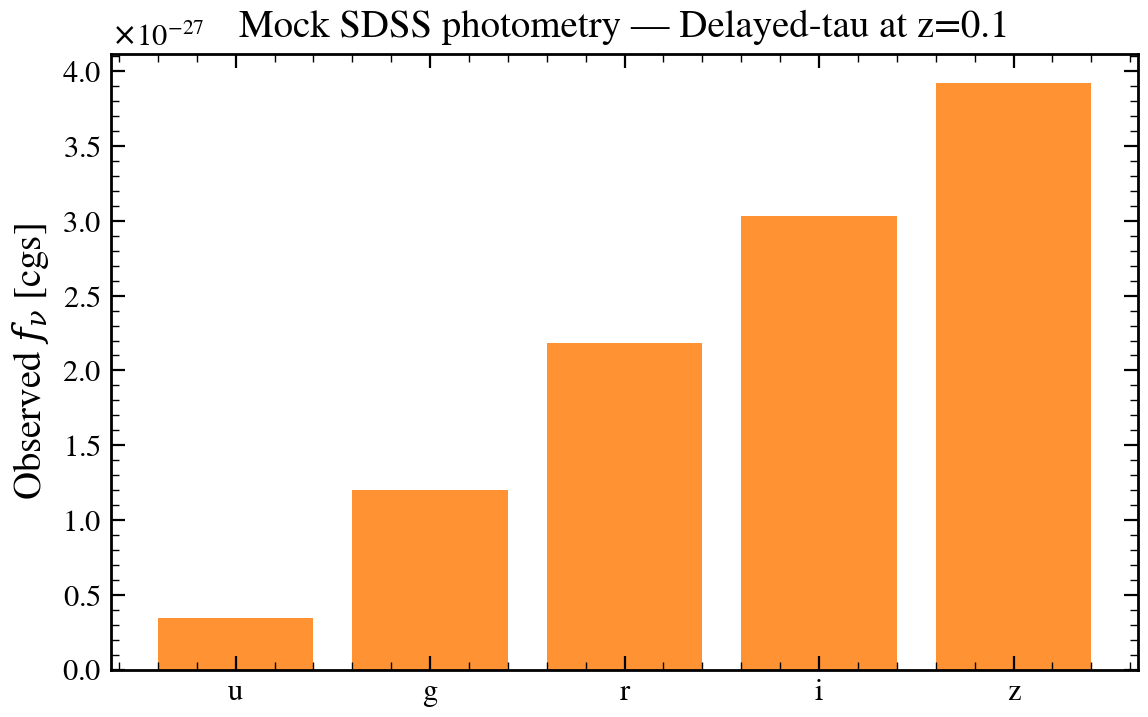

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
band_names = ["u", "g", "r", "i", "z"]
x = np.arange(len(band_names))
ax.bar(x, np.array(phot["flux"]), color=[COLORS["vi"]] * len(band_names), alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(band_names)
ax.set_ylabel(r"Observed $f_\nu$ [cgs]")
ax.set_title(f"Mock SDSS photometry — {name_demo} at z={z_demo}")
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "mock_photometry_bars.png"), dpi=150, bbox_inches="tight")
plt.show()

## 4. Mini-catalog timing

Loop over many galaxies (here 50 random declining SFHs + bursts). For large $N$, compile a
`jax.jit` wrapper around `sed_from_sfh` or batch with `jax.vmap` on a padded grid.

In [8]:
n_galaxies = 50
key = jax.random.PRNGKey(123)
catalog_sfrs = []
catalog_logz = []
for i in range(n_galaxies):
    subkey = jax.random.fold_in(key, i)
    keys = jax.random.split(subkey, 4)
    tau = float(jax.random.uniform(keys[0], minval=1.0, maxval=8.0))
    norm = float(jax.random.uniform(keys[1], minval=1.0, maxval=50.0))
    sfr = norm * np.exp(-t_gyr / tau)
    n_bursts = int(jax.random.poisson(keys[2], 2))
    for b in range(min(n_bursts, 3)):
        burst_key = jax.random.fold_in(keys[3], b)
        burst_time = float(jax.random.uniform(burst_key, minval=2.0, maxval=12.0))
        sfr = sfr + 20.0 * np.exp(-0.5 * ((t_gyr - burst_time) / 0.3) ** 2)
    catalog_sfrs.append(sfr)
    catalog_logz.append(float(jax.random.uniform(keys[3], minval=-1.5, maxval=0.0)))

print(f"Computing SEDs for {n_galaxies} galaxies...")
t0 = time.perf_counter()
catalog_seds = []
for i in range(n_galaxies):
    result = sed_from_sfh(
        jnp.array(t_gyr),
        jnp.array(catalog_sfrs[i]),
        ssp_data,
        log_z=catalog_logz[i],
        dust_tau_bc=0.2,
        dust_tau_diff=0.4,
    )
    catalog_seds.append(result)
elapsed = time.perf_counter() - t0
print(f"Done in {elapsed:.1f}s ({elapsed / n_galaxies * 1000:.0f} ms/galaxy)")

Computing SEDs for 50 galaxies...
Done in 0.2s (3 ms/galaxy)


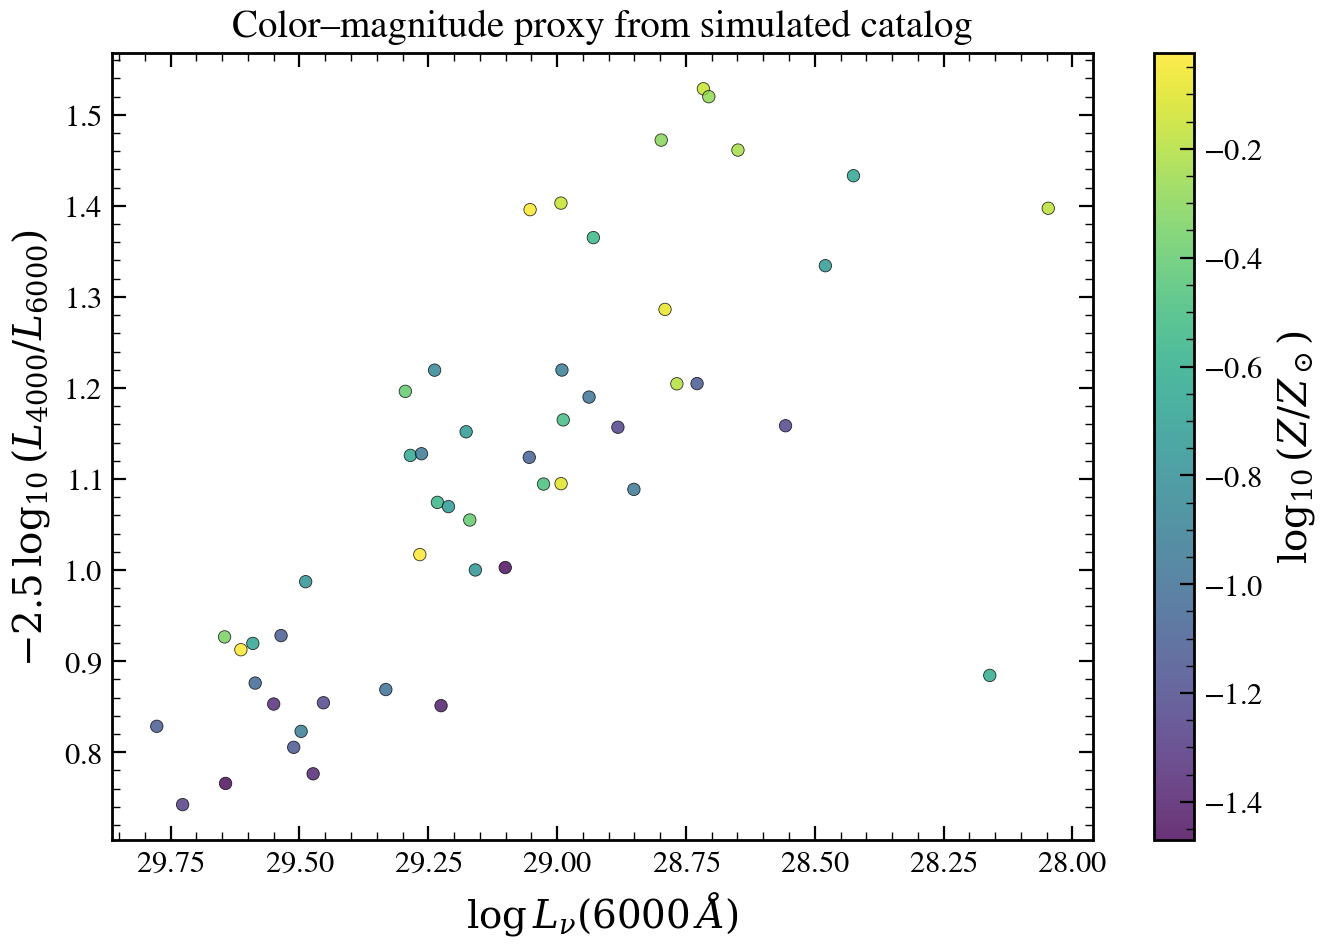

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
color_blue = []
color_red = []
for sed_result in catalog_seds:
    wave = np.array(sed_result["wavelength"])
    sed = np.array(sed_result["sed"])
    idx_blue = int(np.argmin(np.abs(wave - 4000)))
    idx_red = int(np.argmin(np.abs(wave - 6000)))
    color_blue.append(sed[idx_blue])
    color_red.append(sed[idx_red])
color_blue = np.array(color_blue)
color_red = np.array(color_red)
color_ratio = -2.5 * np.log10(np.maximum(color_blue / np.maximum(color_red, 1e-30), 1e-30))

sc = ax.scatter(
    np.log10(np.maximum(color_red, 1e-30)),
    color_ratio,
    c=catalog_logz,
    cmap="viridis",
    s=20,
    alpha=0.8,
    edgecolors="k",
    lw=0.3,
)
plt.colorbar(sc, ax=ax, label=r"$\log_{10}(Z/Z_\odot)$")
ax.set_xlabel(r"$\log L_\nu(6000\,\AA)$")
ax.set_ylabel(r"$-2.5\,\log_{10}(L_{4000}/L_{6000})$")
ax.set_title("Color–magnitude proxy from simulated catalog")
ax.invert_xaxis()
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "color_magnitude_catalog.png"), dpi=150, bbox_inches="tight")
plt.show()

## Summary

| Function | Input | Output |
|----------|-------|--------|
| `sed_from_sfh` | `t_gyr`, `sfr`, `ssp_data` | Rest-frame SED + weights |
| `photometry_from_sfh` | above + `filters`, `redshift` | Observed broadband fluxes |

**Contrast:** this path **generates** SEDs and mocks. **Inference** lives in
[`07_fitting_photometry.py`](07_fitting_photometry.py) and [`08_fitting_spectra.py`](08_fitting_spectra.py).